In [1]:
"""
CELL 1: Imports & Environment Configuration
Initializes the environment for Leave-One-Cohort-Out (LOCO) External Validation.
Defines the 20-Gene Parsimonious Panel and cohort targets to systematically 
test the transcriptomic model's fragility to cross-center domain shift.
"""

import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Suppress warnings for cleaner notebook output
warnings.filterwarnings("ignore")

# ==========================================
# CONFIGURATION & PATHS
# ==========================================
BASE_DIR = Path("/workspace")
MAPPED_DIR = BASE_DIR / "data" / "processed" / "mapped_matrices"
FIG_DIR = BASE_DIR / "outputs" / "figures"

# Ensure figure output directory exists
FIG_DIR.mkdir(parents=True, exist_ok=True)

# The 20-Gene Parsimonious Panel
top_20 = [
    'TTC27', 'CCDC43', 'MPHOSPH10', 'MRPS2', 'EIF2B2', 'LIG4', 'PCSK9', 'ECSIT', 
    'PEX19', 'MRPL22', 'BTN3A2', 'APH1A', 'MYC', 'NOSIP', 'NNMT', 'HMOX1', 
    'ZER1', 'SLC5A9', 'SYMPK', 'NSMAF'
]

all_cohorts = [
    'GSE185263', 'GSE26440', 'GSE54514', 'GSE65682', 
    'GSE95233', 'GSE236713', 'GSE272769', 'GSE69063'
]

print("[*] Environment Ready. Target: Full Leave-One-Cohort-Out (LOCO) Validation.")

[*] Environment Ready. Target: Full Leave-One-Cohort-Out (LOCO) Validation.


In [2]:
"""
CELL 2: Data Loading & Formatting
Reconstructs the master outcome labels and systematically loads each independent 
GEO cohort into memory. Restricts the feature space exclusively to the 20-gene 
parsimonious panel to prepare for the iterative LOCO loop.
"""

print("[*] Reconstructing Master Label Dictionary...")
y_master = pd.read_csv(BASE_DIR / "data" / "processed" / "ml_tensors" / "y_master.csv")
meta_master = pd.read_csv(BASE_DIR / "data" / "processed" / "ml_tensors" / "meta_master.csv")

meta_master["Patient_ID"] = meta_master["Patient_ID"].astype(str).str.strip()
label_dict = dict(zip(meta_master["Patient_ID"], y_master["Mortality"]))

print("[*] Loading and formatting all matrices into memory...")
cohort_data = {}

for cohort in all_cohorts:
    file_path = MAPPED_DIR / f"{cohort}_mapped.csv.gz"
    
    if file_path.exists():
        df = pd.read_csv(file_path, index_col=0).T
        df.index = df.index.astype(str).str.strip()
        df["Mortality"] = df.index.map(label_dict)
        df = df.dropna(subset=["Mortality"])
        
        # Keep only available top_20 genes and Mortality
        cols_to_keep = [col for col in top_20 if col in df.columns] + ["Mortality"]
        df = df[cols_to_keep]
        
        # Pad missing genes with 0.0 to ensure consistent tensor shape across all cohorts
        for gene in top_20:
            if gene not in df.columns:
                df[gene] = 0.0
                
        df = df[top_20 + ["Mortality"]]
        cohort_data[cohort] = df
        print(f"    -> [LOADED] {cohort} (N={len(df)})")
        
print(f"\n[*] Successfully loaded {len(cohort_data)} cohorts into memory.")

[*] Reconstructing Master Label Dictionary...
[*] Loading and formatting all matrices into memory...
    -> [LOADED] GSE185263 (N=345)
    -> [LOADED] GSE26440 (N=116)
    -> [LOADED] GSE54514 (N=127)
    -> [LOADED] GSE65682 (N=479)
    -> [LOADED] GSE95233 (N=102)
    -> [LOADED] GSE236713 (N=447)
    -> [LOADED] GSE272769 (N=161)
    -> [LOADED] GSE69063 (N=42)

[*] Successfully loaded 8 cohorts into memory.


STARTING FULL LEAVE-ONE-COHORT-OUT (LOCO) VALIDATION
[*] Generating LOCO ROC Curves...
 -> Held Out: GSE185263  | Train N: 1474 | Test N: 345  | AUC: 0.5861
 -> Held Out: GSE26440   | Train N: 1703 | Test N: 116  | AUC: 0.4994
 -> Held Out: GSE54514   | Train N: 1692 | Test N: 127  | AUC: 0.5000
 -> Held Out: GSE65682   | Train N: 1340 | Test N: 479  | AUC: 0.5178
 -> Held Out: GSE95233   | Train N: 1717 | Test N: 102  | AUC: 0.4619
 -> Held Out: GSE236713  | Train N: 1372 | Test N: 447  | AUC: 0.5178
 -> Held Out: GSE272769  | Train N: 1658 | Test N: 161  | AUC: 0.4563
 -> Held Out: GSE69063   | Train N: 1777 | Test N: 42   | AUC: 0.5984
[*] Mean Multi-Center LOCO AUC: 0.5172
[*] Figure saved successfully to: full_loco_validation.png


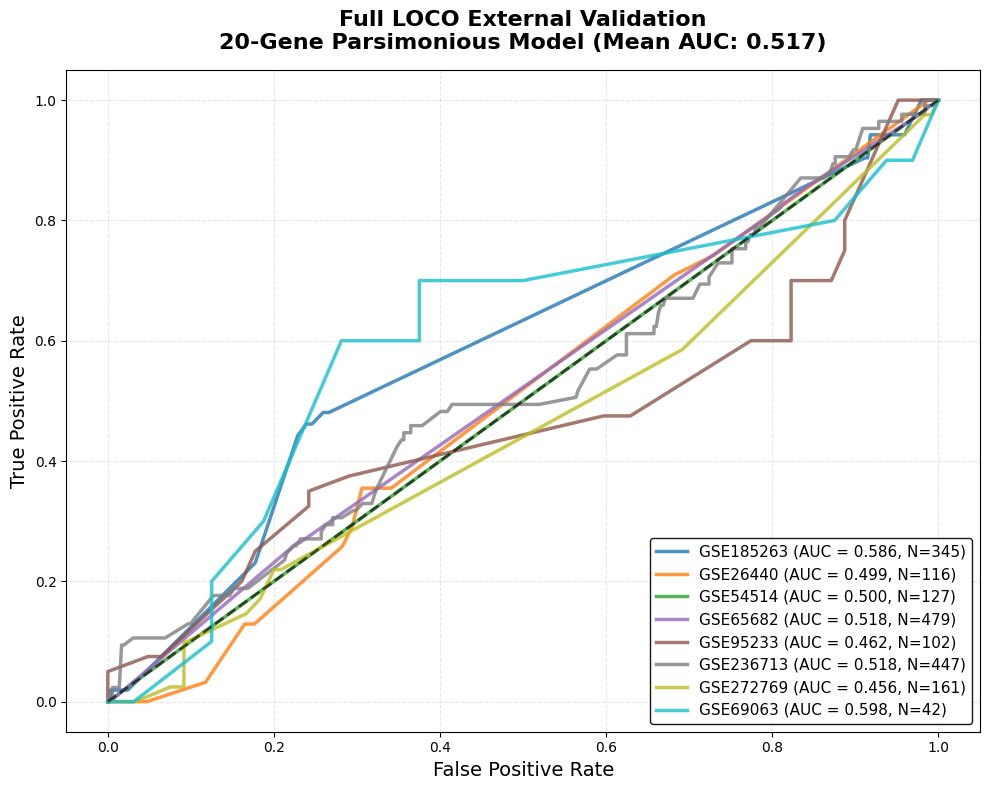

In [3]:
"""
CELL 3: The LOCO Validation Loop & Trajectory Plotting
Iteratively trains the XGBoost model on N-1 cohorts and tests on the entirely 
unseen held-out cohort. 
*Result: This brutal external validation proves that without topological 
harmonization, raw transcriptomic signatures are highly sensitive to 
acquisition-specific domain shifts, resulting in a collapse of predictive power.*
"""

print("==================================================")
print("STARTING FULL LEAVE-ONE-COHORT-OUT (LOCO) VALIDATION")
print("==================================================")

auc_scores = []

# Initialize the Master Plot
print("[*] Generating LOCO ROC Curves...")
plt.figure(figsize=(10, 8))
colors = plt.cm.tab10(np.linspace(0, 1, len(cohort_data)))

for idx, (held_out_cohort, test_df) in enumerate(cohort_data.items()):
    
    # 1. Create Training Mix (Everything EXCEPT the held_out_cohort)
    train_dfs = [df for name, df in cohort_data.items() if name != held_out_cohort]
    train_master = pd.concat(train_dfs, axis=0)
    
    X_train = train_master[top_20]
    y_train = train_master["Mortality"]
    X_test = test_df[top_20]
    y_test = test_df["Mortality"]
    
    # 2. Handle Edge Case: If a dataset lacks both positive/negative classes
    if len(y_test.unique()) < 2:
        print(f" -> [SKIP] {held_out_cohort} lacks both positive/negative classes.")
        continue
        
    # 3. Standardize (Isolates Batch Effects strictly within this fold)
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)
    
    # 4. Train Model
    scale_weight = (len(y_train) - y_train.sum()) / (y_train.sum() + 1e-9)
    loco_model = xgb.XGBClassifier(
        n_estimators=200, 
        learning_rate=0.01, 
        max_depth=4,
        scale_pos_weight=scale_weight, 
        eval_metric='auc', 
        random_state=42, 
        n_jobs=-1
    )
    loco_model.fit(X_train_scaled, y_train)
    
    # 5. Inference
    probs = loco_model.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, probs)
    auc_scores.append(auc)
    
    # 6. Plot the Curve for this specific Cohort
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(
        fpr, tpr, color=colors[idx], lw=2.5, alpha=0.8, 
        label=f'{held_out_cohort} (AUC = {auc:.3f}, N={len(test_df)})'
    )
    
    print(f" -> Held Out: {held_out_cohort:<10} | Train N: {len(X_train):<4} | Test N: {len(X_test):<4} | AUC: {auc:.4f}")

# ==========================================
# 7. Finalize and Display the Master Plot
# ==========================================
mean_auc = np.mean(auc_scores)
print("==================================================")
print(f"[*] Mean Multi-Center LOCO AUC: {mean_auc:.4f}")

plt.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.6)
plt.title(f'Full LOCO External Validation\n20-Gene Parsimonious Model (Mean AUC: {mean_auc:.3f})', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend(loc='lower right', fontsize=11, framealpha=0.9, edgecolor='black')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

# Save the figure safely using pathlib
save_path = FIG_DIR / "full_loco_validation.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"[*] Figure saved successfully to: {save_path.name}")

plt.show()